In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

# Part 0: Data Preparation And Preprocessing

## EDA

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [79]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


In [80]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [81]:
df['workclass'].value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


### insight
- i will use **`Onehot encode for this`**
- has 2799 Nan i will use mode to fill **`Around 75% is Private`**

In [82]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Transport-moving,2355
Handlers-cleaners,2072


### Insights
- I will use **`One Hot encode`**
- For Nan i will use **`Replace with Un-Known`**

In [83]:
df['native-country'].value_counts()

,count
native-country,
United-States,43832
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


### Insights
- i will Fill Nan with `UNknown`
- Then put Replace all others "None top 10" with `Other`
#### We will have now ~11 column Not 41 After One Hot

In [84]:
df['occupation'] = df['occupation'].cat.add_categories('Unknown')
df['native-country'] = df['native-country'].cat.add_categories('Unknown')

In [85]:
mode_value = df['workclass'].mode()[0]
df['workclass'] = df['workclass'].fillna(mode_value)
df['occupation'] = df['occupation'].fillna('Unknown')
df['native-country'] = df['native-country'].fillna('Unknown')

In [86]:
print(df[['workclass', 'occupation', 'native-country']].isna().sum())

workclass         0
occupation        0
native-country    0
dtype: int64


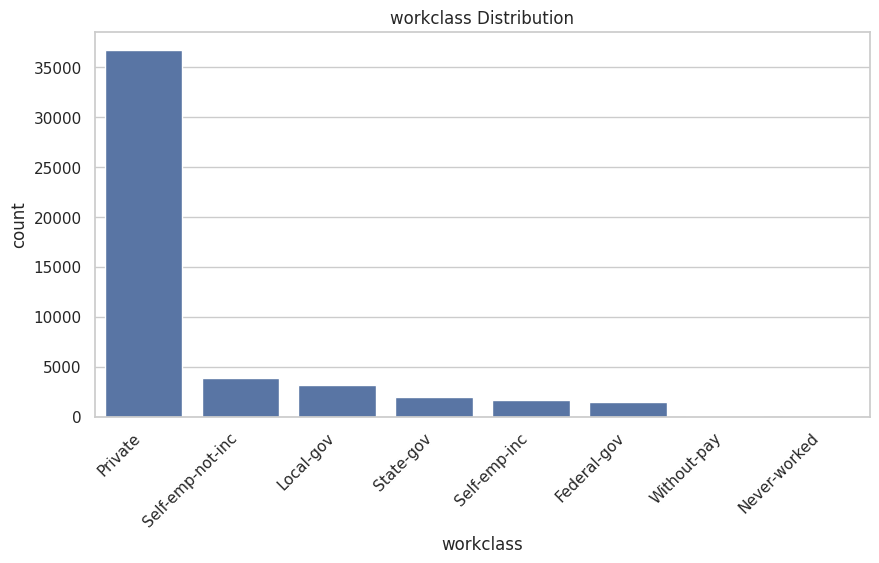

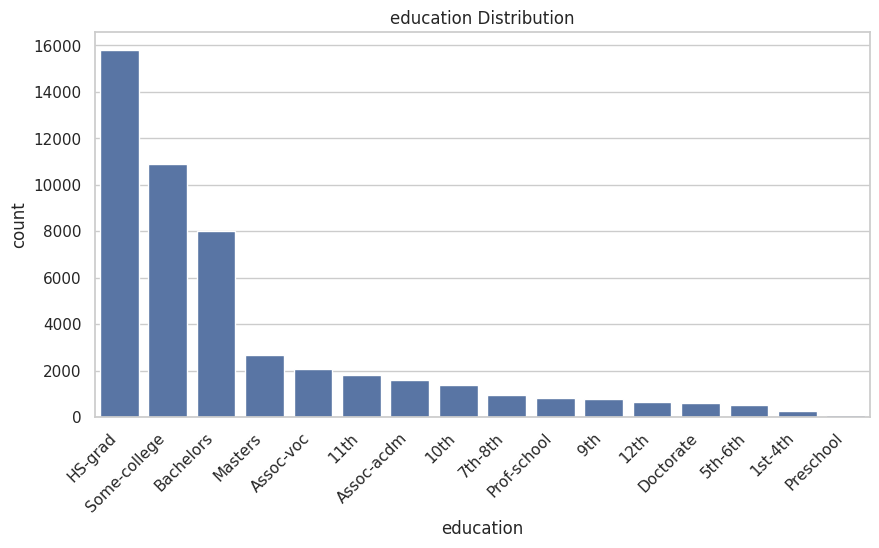

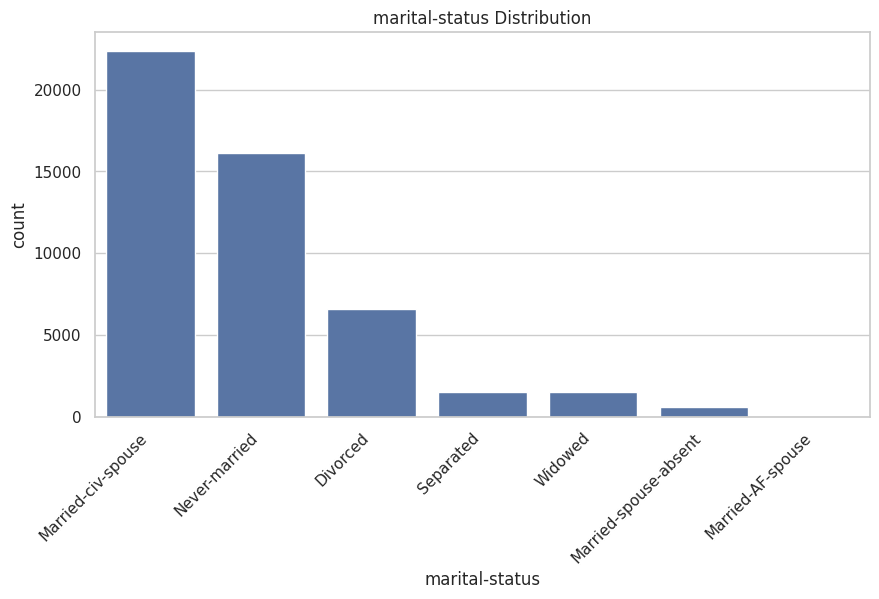

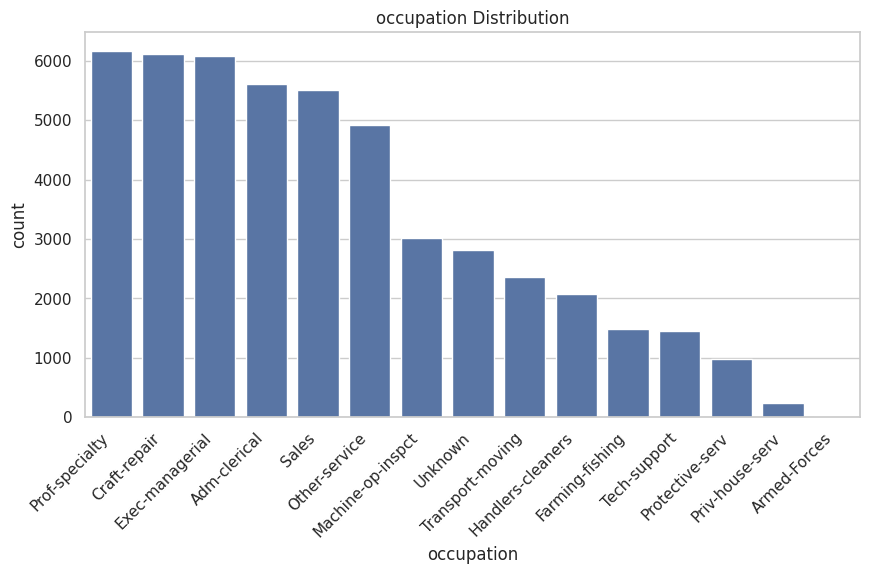

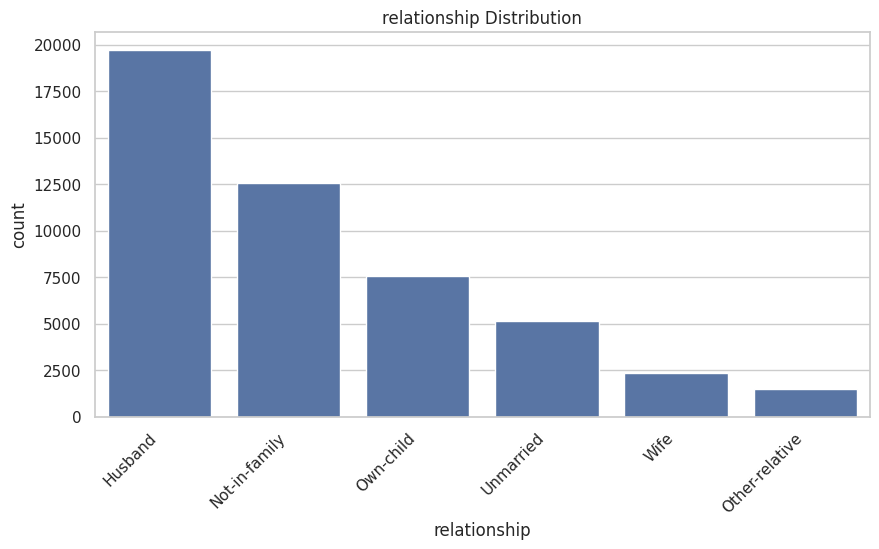

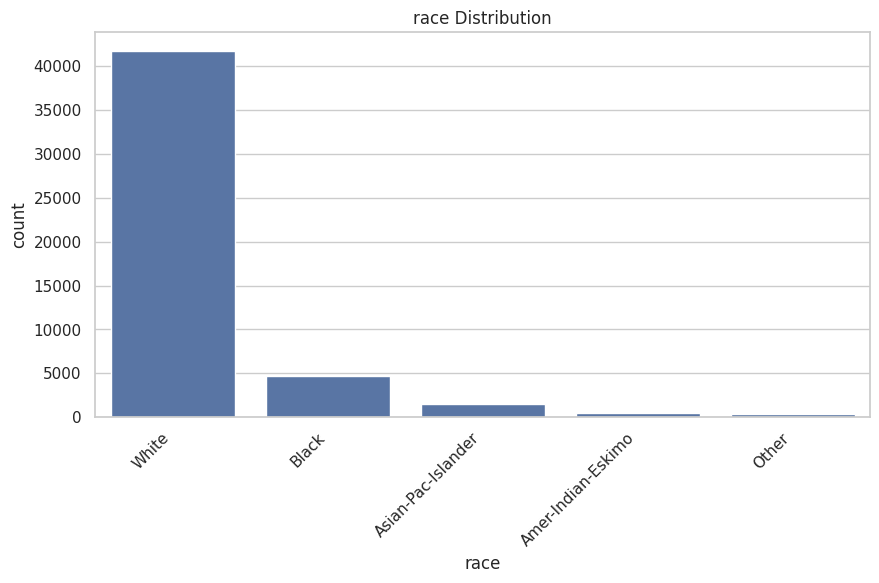

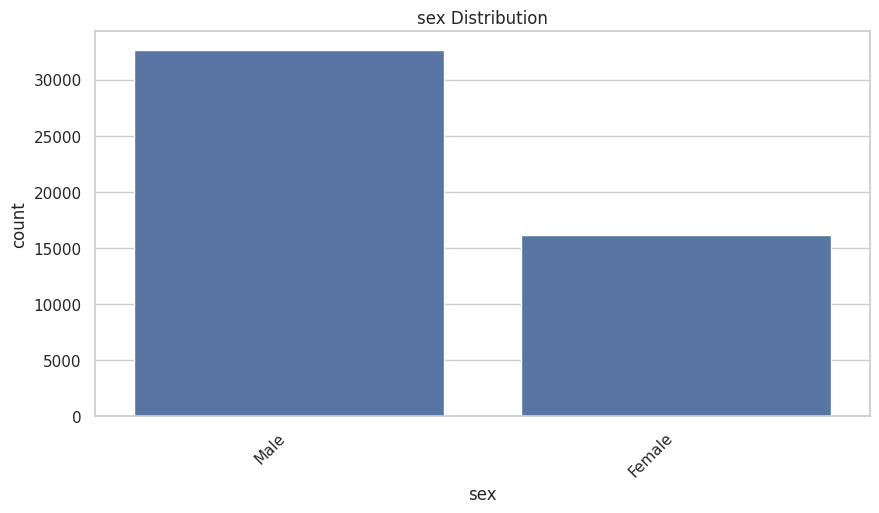

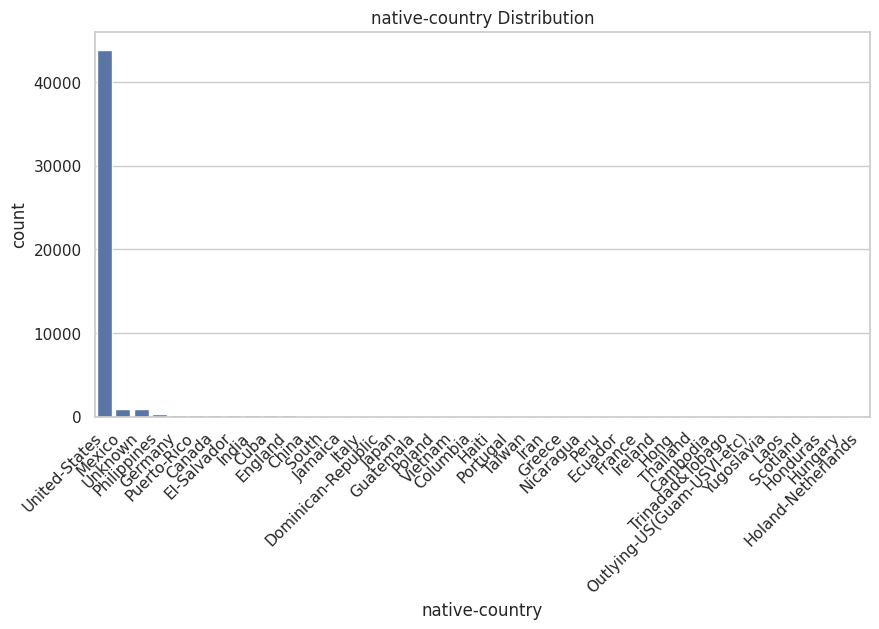

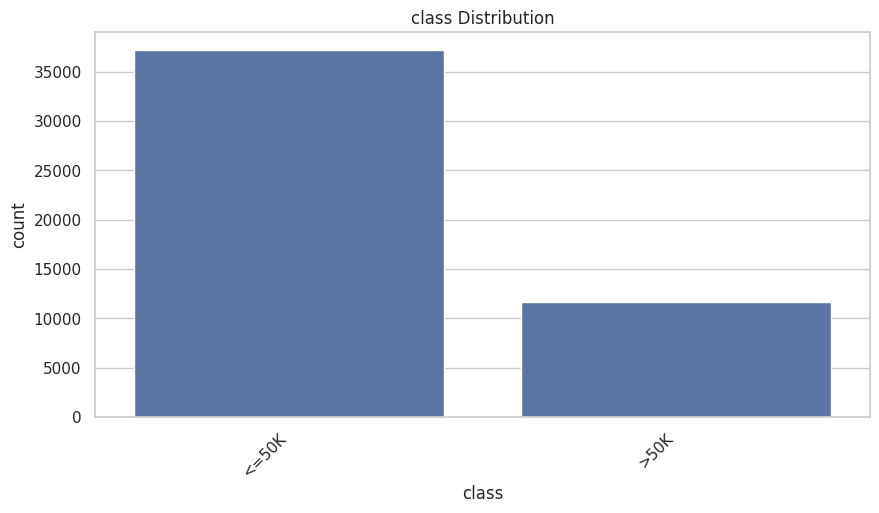

In [87]:
%matplotlib inline
sns.set(style="whitegrid")
categorical_cols = df.select_dtypes(include='category').columns
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} Distribution')
    plt.show()

In [88]:
df['education'].value_counts()

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [89]:
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

df['education_ord'] = df['education'].apply(lambda x: education_order.index(x))

In [90]:
df['education-num'].nunique(), df['education-num'].max()

(16, 16)

In [91]:
df[df['education-num'] == 1]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,education_ord
779,64,Private,86837,Preschool,1,Married-civ-spouse,Handlers-cleaners,Husband,Asian-Pac-Islander,Male,0,0,40,Philippines,<=50K,0
818,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,25,Mexico,<=50K,0
1029,57,Private,274680,Preschool,1,Separated,Unknown,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
1059,31,Private,25610,Preschool,1,Never-married,Handlers-cleaners,Not-in-family,Amer-Indian-Eskimo,Male,0,0,25,United-States,<=50K,0
1489,19,Private,277695,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48079,31,State-gov,77634,Preschool,1,Never-married,Other-service,Not-in-family,White,Male,0,0,24,United-States,<=50K,0
48316,40,Private,566537,Preschool,1,Married-civ-spouse,Other-service,Husband,White,Male,0,1672,40,Mexico,<=50K,0
48505,40,Private,70645,Preschool,1,Never-married,Other-service,Not-in-family,White,Female,0,0,20,United-States,<=50K,0
48640,46,Private,139514,Preschool,1,Married-civ-spouse,Machine-op-inspct,Other-relative,Black,Male,0,0,75,Dominican-Republic,<=50K,0


### Insights
- Drop education and education_ord

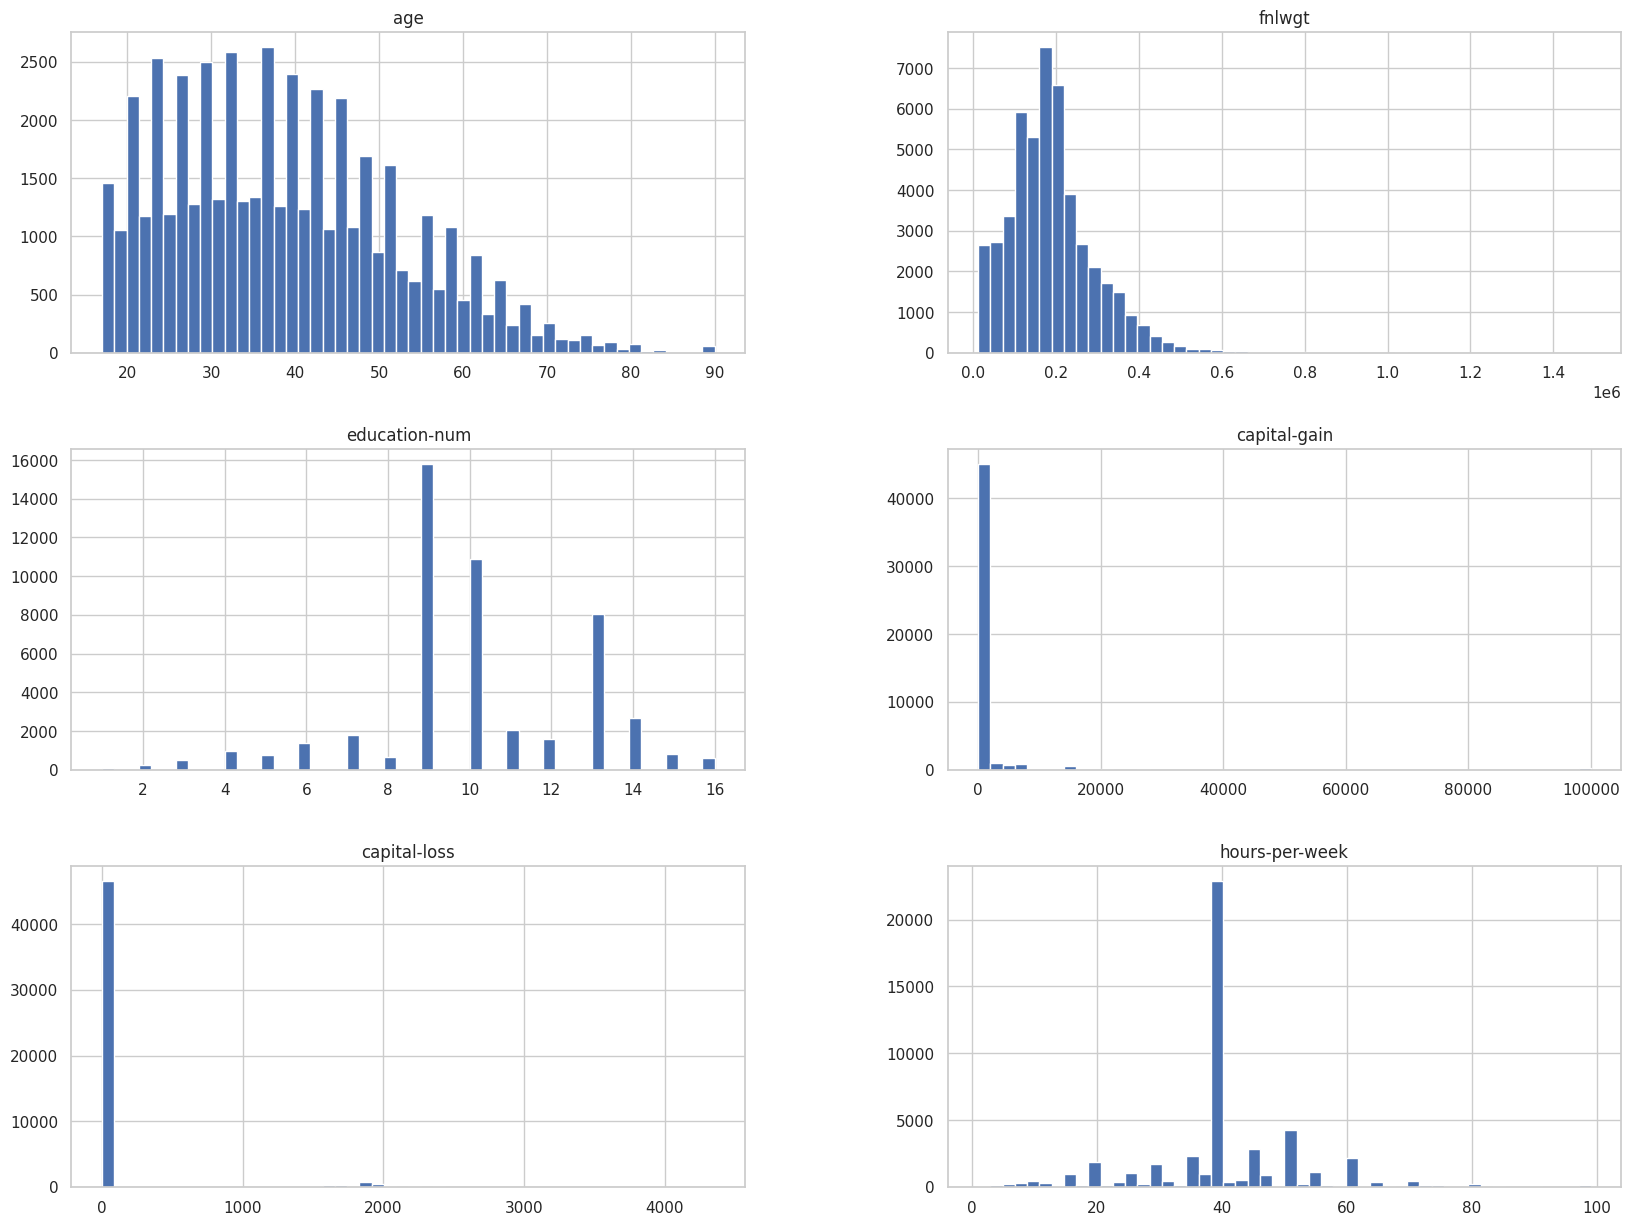

In [92]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [93]:
import numpy as np

df['fnlwgt'] = np.log1p(df['fnlwgt'])
df['capital-gain'] = np.log1p(df['capital-gain'])
df['capital-loss'] = np.log1p(df['capital-loss'])

In [94]:
df.drop(['education', 'education_ord'], axis=1, inplace=True)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       48842 non-null  category
 2   fnlwgt          48842 non-null  float64 
 3   education-num   48842 non-null  int64   
 4   marital-status  48842 non-null  category
 5   occupation      48842 non-null  category
 6   relationship    48842 non-null  category
 7   race            48842 non-null  category
 8   sex             48842 non-null  category
 9   capital-gain    48842 non-null  float64 
 10  capital-loss    48842 non-null  float64 
 11  hours-per-week  48842 non-null  int64   
 12  native-country  48842 non-null  category
 13  class           48842 non-null  category
dtypes: category(8), float64(3), int64(3)
memory usage: 2.6 MB


In [96]:
top = df['native-country'].value_counts().nlargest(10).index
df['native-country'] = df['native-country'].apply(lambda x: x if x in top else 'Other')

In [97]:
df['native-country'].value_counts()

,count
native-country,
United-States,43832
Other,1891
Mexico,951
Unknown,857
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155


In [98]:
X = df.drop('class', axis=1)
y = df['class']

In [99]:
cat_cols = X.select_dtypes(include='category').columns

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [102]:
cat_cols

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex'],
      dtype='object')

In [100]:
y_encoded = y.map({'<=50K': 0, '>50K': 1})

In [101]:
X_encoded.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,25,12.331837,7,0.000000,0.0,40,United-States,False,False,True,...,False,False,True,False,False,False,True,False,False,True
1,38,11.405507,9,0.000000,0.0,50,United-States,False,False,True,...,False,False,False,False,False,False,False,False,True,True
2,28,12.727696,12,0.000000,0.0,40,United-States,True,False,False,...,False,False,False,False,False,False,False,False,True,True
3,44,11.984952,10,8.947546,0.0,40,United-States,False,False,True,...,False,False,False,False,False,False,True,False,False,True
4,18,11.547308,10,0.000000,0.0,30,United-States,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [103]:
X_encoded = pd.get_dummies(X_encoded, columns=['native-country'], drop_first=True)

In [104]:
X_encoded.shape

(48842, 53)

In [106]:
X_encoded.dtypes

,0
age,int64
fnlwgt,float64
education-num,int64
capital-gain,float64
capital-loss,float64
hours-per-week,int64
workclass_Local-gov,bool
workclass_Never-worked,bool
workclass_Private,bool
workclass_Self-emp-inc,bool


In [109]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [154]:
y_train.value_counts(normalize=True)

,proportion
class,
0,0.760713
1,0.239287


In [116]:
from sklearn.preprocessing import StandardScaler

# Identify numerical and boolean columns
num_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns
bool_cols = X_encoded.select_dtypes(include='bool').columns

# Convert boolean columns to int type before scaling
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)
X_val[bool_cols] = X_val[bool_cols].astype(int)

# Scale numerical columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# Part 1: Train NN

In [111]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

In [170]:
def create_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

In [181]:
def train_model(optimizer, X_train, y_train, X_val, y_val, epochs=25, batch_size=128):
    model = create_model()
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, verbose=0)
    return model, history

In [203]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
def evalute(model,X_test,y_test):
    y_prob = model.predict(X_test.to_numpy()).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    cr = classification_report(y_test, y_pred, digits=4)
    print("Classification Report:")
    print(cr)
    auc = roc_auc_score(y_test, y_prob)
    print("AUC:", auc)

In [182]:
model_sgd, history_sgd = train_model(SGD(learning_rate=0.01), X_train.to_numpy(), y_train.to_numpy(),
                          X_val.to_numpy(), y_val.to_numpy())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [204]:
evalute(model_sgd, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step
Confusion Matrix:
[[5217  357]
 [ 745 1008]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8750    0.9360    0.9045      5574
           1     0.7385    0.5750    0.6466      1753

    accuracy                         0.8496      7327
   macro avg     0.8068    0.7555    0.7755      7327
weighted avg     0.8424    0.8496    0.8428      7327

AUC: 0.899999508761545


In [183]:
model_momentum, history_momentum = train_model(SGD(learning_rate=0.01, momentum=0.9), X_train.to_numpy(), y_train.to_numpy(),
                               X_val.to_numpy(), y_val.to_numpy())

In [205]:
evalute(model_momentum, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step
Confusion Matrix:
[[5082  492]
 [ 587 1166]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8965    0.9117    0.9040      5574
           1     0.7033    0.6651    0.6837      1753

    accuracy                         0.8527      7327
   macro avg     0.7999    0.7884    0.7938      7327
weighted avg     0.8502    0.8527    0.8513      7327

AUC: 0.9061422409602402


In [184]:
model_adam, history_adam = train_model(Adam(learning_rate=0.001), X_train.to_numpy(), y_train.to_numpy(),
                           X_val.to_numpy(), y_val.to_numpy())

In [206]:
evalute(model_adam, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
Confusion Matrix:
[[5284  290]
 [ 802  951]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8682    0.9480    0.9063      5574
           1     0.7663    0.5425    0.6353      1753

    accuracy                         0.8510      7327
   macro avg     0.8173    0.7452    0.7708      7327
weighted avg     0.8438    0.8510    0.8415      7327

AUC: 0.9049516017546219


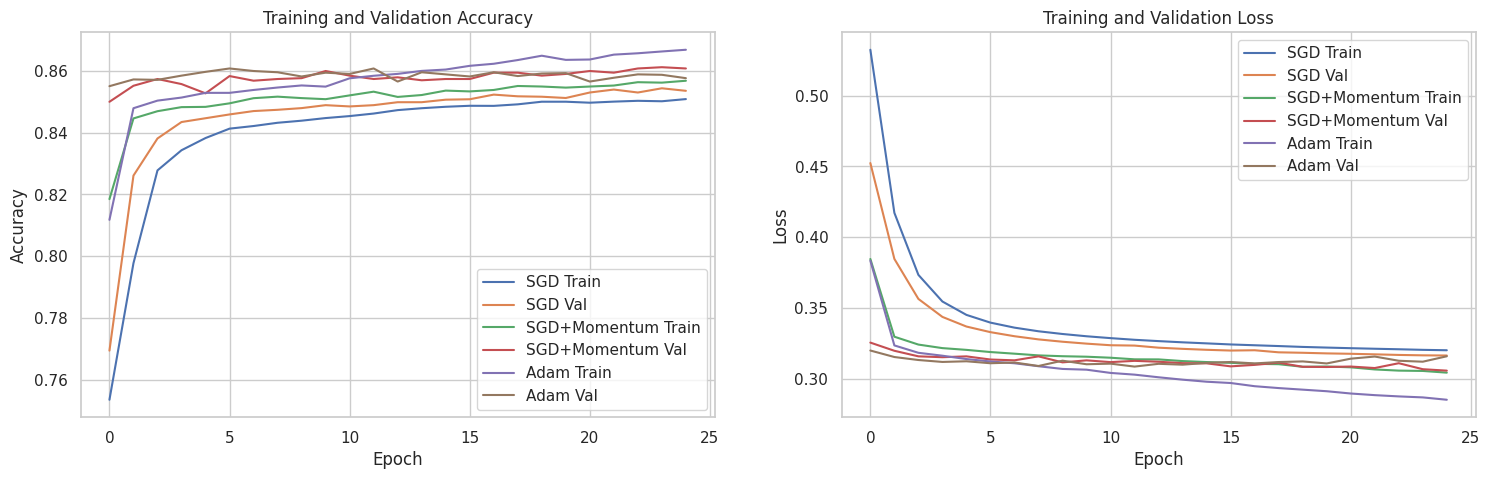

In [178]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='SGD Train')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val')
plt.plot(history_momentum.history['accuracy'], label='SGD+Momentum Train')
plt.plot(history_momentum.history['val_accuracy'], label='SGD+Momentum Val')
plt.plot(history_adam.history['accuracy'], label='Adam Train')
plt.plot(history_adam.history['val_accuracy'], label='Adam Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'], label='SGD Train')
plt.plot(history_sgd.history['val_loss'], label='SGD Val')
plt.plot(history_momentum.history['loss'], label='SGD+Momentum Train')
plt.plot(history_momentum.history['val_loss'], label='SGD+Momentum Val')
plt.plot(history_adam.history['loss'], label='Adam Train')
plt.plot(history_adam.history['val_loss'], label='Adam Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

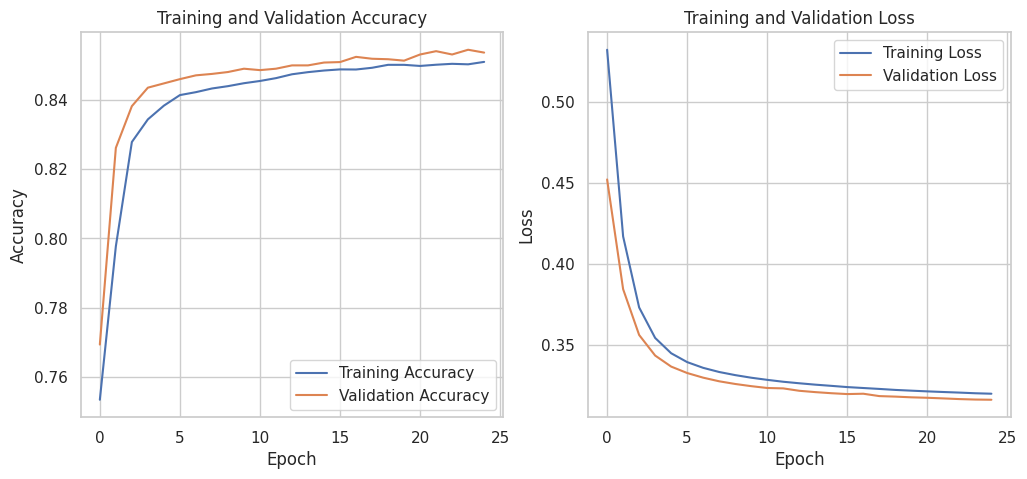

In [175]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'], label='Training Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

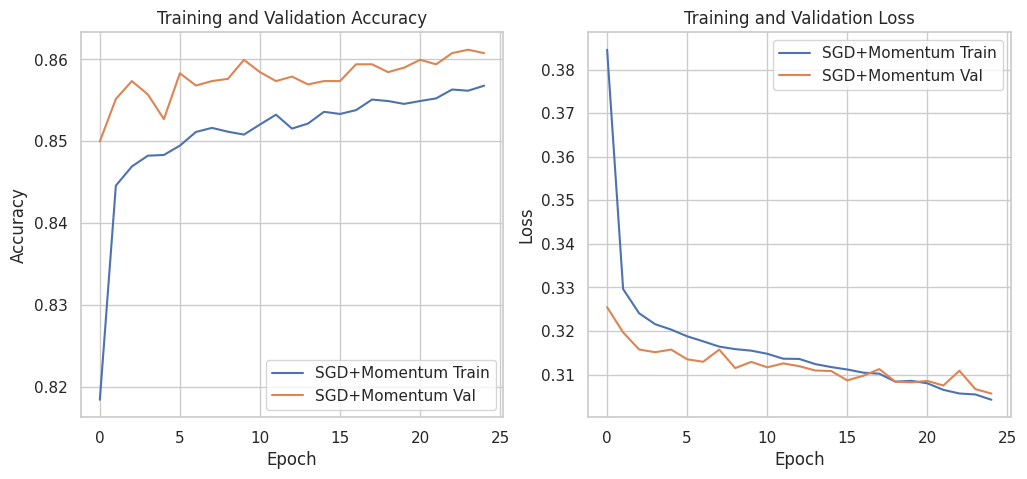

In [176]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_momentum.history['accuracy'], label='SGD+Momentum Train')
plt.plot(history_momentum.history['val_accuracy'], label='SGD+Momentum Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_momentum.history['loss'], label='SGD+Momentum Train')
plt.plot(history_momentum.history['val_loss'], label='SGD+Momentum Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

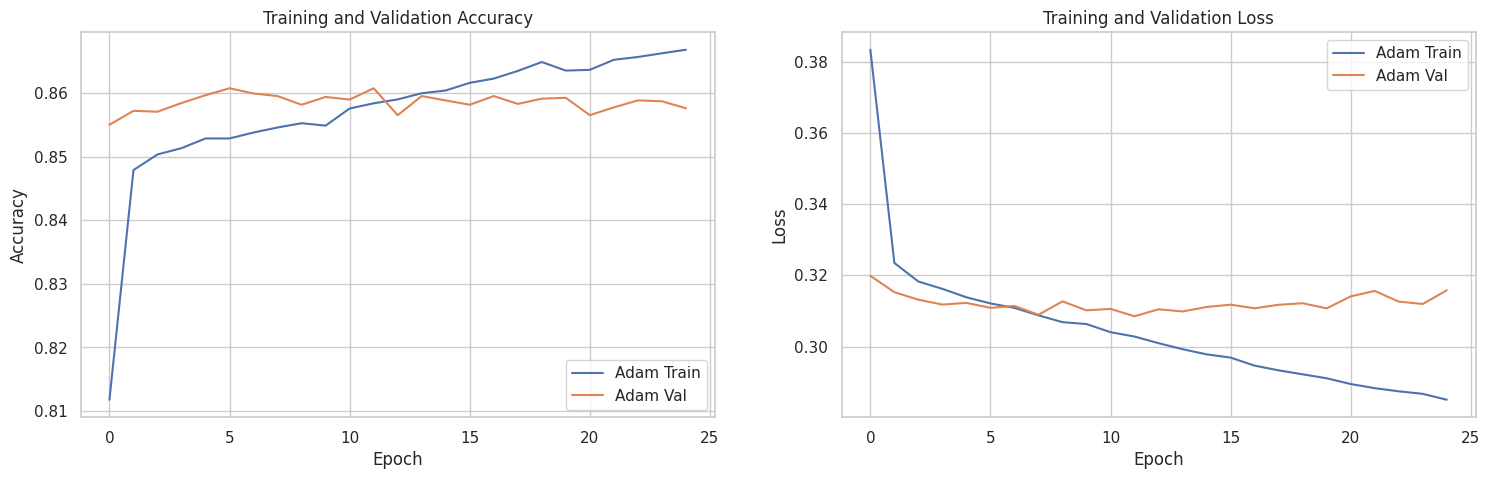

In [177]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Adam Train')
plt.plot(history_adam.history['val_accuracy'], label='Adam Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'], label='Adam Train')
plt.plot(history_adam.history['val_loss'], label='Adam Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Fastest convergence: Adam

Best generalization: SGD (sometimes) Adam can overfit faster on small datasets

---

Why Adam often performs better than SGD:

- Adam remembers past gradients (momentum) → smoother updates.

- Adam adjusts learning rate for each weight → faster learning.

- SGD updates all weights equally → slower and may need more tuning.

## Part 2: Batch Size

In [196]:
def train_with_batch(batch_size):
  model, history = train_model(Adam(learning_rate=0.001), X_train.to_numpy(), y_train.to_numpy(),X_val.to_numpy(), y_val.to_numpy(), batch_size=batch_size)
  evalute(model, X_test, y_test)
  return history


Training with batch size: 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step
Confusion Matrix:
[[5117  457]
 [ 647 1106]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8878    0.9180    0.9026      5574
           1     0.7076    0.6309    0.6671      1753

    accuracy                         0.8493      7327
   macro avg     0.7977    0.7745    0.7848      7327
weighted avg     0.8447    0.8493    0.8463      7327

AUC: 0.9023384178560266

Training with batch size: 128


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step
Confusion Matrix:
[[5178  396]
 [ 675 1078]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8847    0.9290    0.9063      5574
           1     0.7313    0.6149    0.6681      1753

    accuracy                         0.8538      7327
   macro avg     0.8080    0.7720    0.7872      7327
weighted avg     0.8480    0.8538    0.8493      7327

AUC: 0.9045699708797937

Training with batch size: 256


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step
Confusion Matrix:
[[5187  387]
 [ 682 1071]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8838    0.9306    0.9066      5574
           1     0.7346    0.6110    0.6671      1753

    accuracy                         0.8541      7327
   macro avg     0.8092    0.7708    0.7868      7327
weighted avg     0.8481    0.8541    0.8493      7327

AUC: 0.908207079933298

Training with batch size: 1024


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step
Confusion Matrix:
[[5176  398]
 [ 686 1067]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8830    0.9286    0.9052      5574
           1     0.7283    0.6087    0.6631      1753

    accuracy                         0.8521      7327
   macro avg     0.8057    0.7686    0.7842      7327
weighted avg     0.8460    0.8521    0.8473      7327

AUC: 0.905448520154388


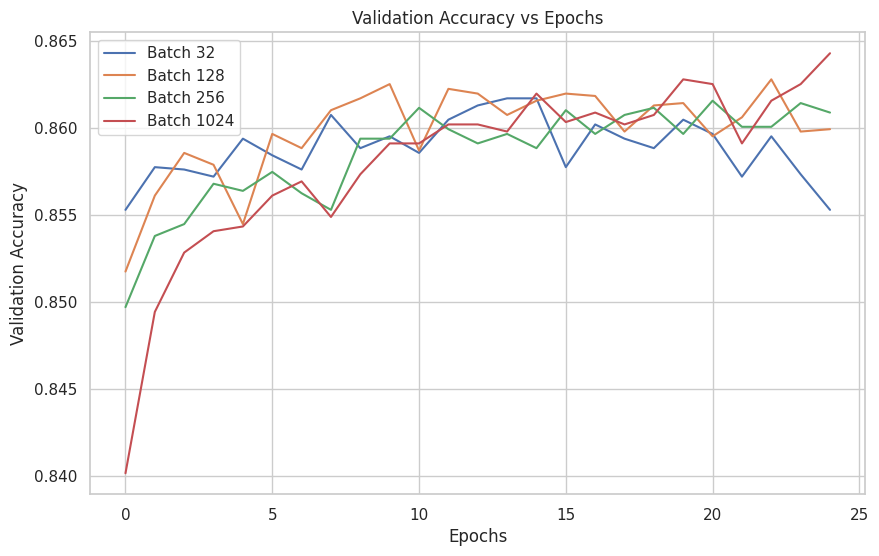

In [207]:
batch_sizes = [32, 128, 256,1024]

histories = {}
test_accuracies = {}

for batch in batch_sizes:
    print(f"\nTraining with batch size: {batch}")
    history = train_with_batch(batch)
    histories[batch] = history

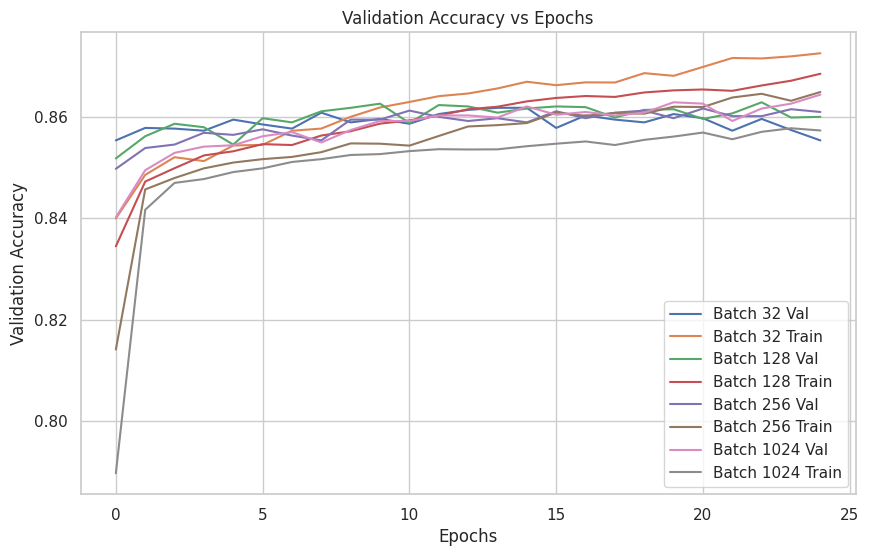

In [209]:
plt.figure(figsize=(10,6))
for batch in batch_sizes:
    plt.plot(histories[batch].history['val_accuracy'], label=f'Batch {batch} Val')
    plt.plot(histories[batch].history['accuracy'], label=f'Batch {batch} Train')
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

3. Which batch size leads to the noisiest gradient updates?

The Batch 32 smaller batch sizes provide a more stochastic (random) estimate of the true gradient of the entire dataset

4. Which batch size generalizes better and why?

In this specific graph, Batch 32
- Smaller batches generalize better by finding flat minima, which are robust to data shifts, whereas large batches often get stuck in sharp minima that are more sensitive and prone to error.

# Part 3: Overfitting and Regularization

In [210]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

In [212]:
model_l2 = Sequential([
    Dense(256, input_shape=(X_train.shape[1],), activation='relu', kernel_regularizer=l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l2 = model_l2.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    validation_data=(X_val.to_numpy(), y_val.to_numpy()),
    epochs=25,
    batch_size=32,
    verbose=0
)

In [213]:
evalute(model_l2, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[5263  311]
 [ 732 1021]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8779    0.9442    0.9098      5574
           1     0.7665    0.5824    0.6619      1753

    accuracy                         0.8576      7327
   macro avg     0.8222    0.7633    0.7859      7327
weighted avg     0.8512    0.8576    0.8505      7327

AUC: 0.9098881388632865


In [215]:
model_dropout = Sequential([
    Dense(256, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    validation_data=(X_val.to_numpy(), y_val.to_numpy()),
    epochs=25,
    batch_size=32,
    verbose=0
)

In [216]:
evalute(model_dropout, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion Matrix:
[[5170  404]
 [ 662 1091]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8865    0.9275    0.9065      5574
           1     0.7298    0.6224    0.6718      1753

    accuracy                         0.8545      7327
   macro avg     0.8081    0.7749    0.7892      7327
weighted avg     0.8490    0.8545    0.8504      7327

AUC: 0.9059923108900809


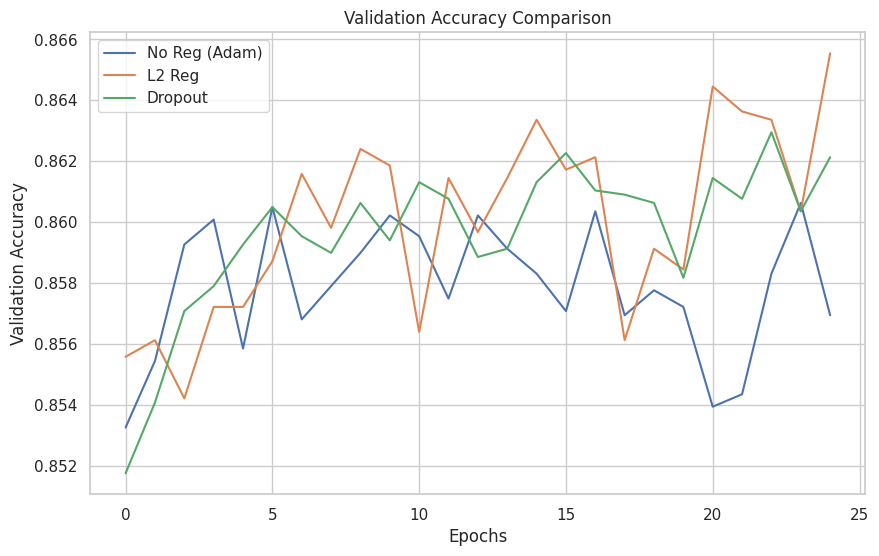

In [218]:
plt.figure(figsize=(10,6))
plt.plot(history_adam.history['val_accuracy'], label='No Reg (Adam)')
plt.plot(history_l2.history['val_accuracy'], label='L2 Reg')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

4. Compare the validation results before and after regularization.

Overall regularization improve L2 is much better

Why L2 worked better:

- L2 adds a penalty on large weights, forcing the network to keep weights small.

- This reduces model complexity, preventing it from fitting noise in the training data.

- In your dataset, the network benefited more from weight smoothing than from randomly dropping neurons (Dropout).

- Result: training and validation accuracy curves are closer, and the model generalizes better.

# Part 4: Early Stopping

In [219]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

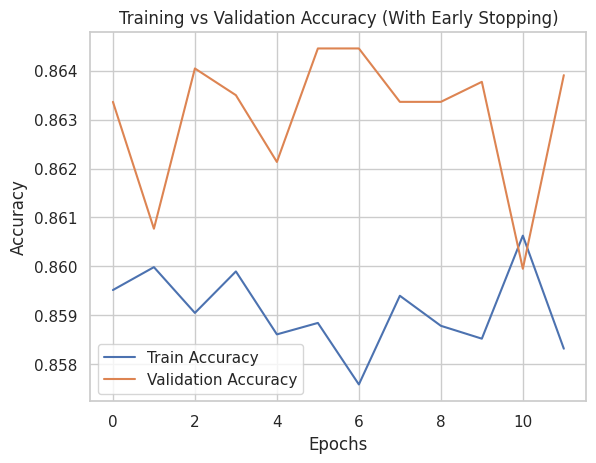

In [222]:
history_es = model_l2.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    validation_data=(X_val.to_numpy(), y_val.to_numpy()),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

plt.plot(history_es.history['accuracy'], label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy (With Early Stopping)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [223]:
evalute(model_l2, X_test, y_test)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion Matrix:
[[5175  399]
 [ 668 1085]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8857    0.9284    0.9065      5574
           1     0.7311    0.6189    0.6704      1753

    accuracy                         0.8544      7327
   macro avg     0.8084    0.7737    0.7885      7327
weighted avg     0.8487    0.8544    0.8500      7327

AUC: 0.9108518873074423


### only ~11 epochs Vs 25 epochs

# Part 5: Reflection

Optimizers

SGD: Simple optimizer; slower convergence but sometimes better generalization.

SGD with Momentum: Faster than SGD; reduces oscillations and improves convergence.

Adam: Combines momentum and adaptive learning rates → fastest convergence and strong performance.

Batch Size

Small batches (e.g., 32): Noisy gradients → help escape sharp minima → often better generalization.

Large batches (e.g., 1024): Stable gradients and faster computation → but may generalize worse.

Regularization

L2 Regularization: Penalizes large weights → reduces model complexity → helped reduce overfitting best in this experiment.

Dropout: Randomly disables neurons during training → prevents neuron co-adaptation and improves robustness.

Early Stopping

Stops training when validation performance stops improving.

Prevents overfitting and reduces unnecessary training epochs.

Data Splits

Training set: Used to learn model parameters.

Validation set: Used for tuning hyperparameters and preventing overfitting.

Test set: Used for final unbiased evaluation.

Recommended Choices for a New Tabular Dataset

Optimizer: Adam → fast convergence and minimal tuning.

Batch Size: 32–128 → good balance between noise and stability.

Regularization: Start with L2 regularization; add dropout if overfitting persists.

Early Stopping: Enable with monitor='val_loss', patience 5–10.

Data Split: Stratified 70/15/15 or 80/10/10 to maintain class balance and reliable evaluation.

Main Insight:
Balanced training choices (Adam optimizer, moderate batch size, L2 regularization, and early stopping) help achieve fast training, reduced overfitting, and better generalization.

In [224]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

In [226]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc"
)
evalute(lgb_model, X_test, y_test)

[LightGBM] [Info] Number of positive: 8181, number of negative: 26008
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 34189, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239287 -> initscore=-1.156590
[LightGBM] [Info] Start training from score -1.156590


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix:
[[5246  328]
 [ 617 1136]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8948    0.9412    0.9174      5574
           1     0.7760    0.6480    0.7062      1753

    accuracy                         0.8710      7327
   macro avg     0.8354    0.7946    0.8118      7327
weighted avg     0.8663    0.8710    0.8669      7327

AUC: 0.7945936547138117
